In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd

from utils import parse_latencies, parse_power_log, get_power_index, compute_layer_metrics_by_cycle

In [2]:
DATA_PATH = Path('../raw_data/single_conv_layer')

In [3]:
with open((DATA_PATH/'idling_power.json'), 'r') as fp:
    data = json.load(fp)

avg_power = data['avg_idle_power']
print(f'Average power consumed in IDLE state: {avg_power}')

Average power consumed in IDLE state: 3579178.0650697174


## Single Convolution Layers


### Kernel 1 Stride 1 Output 3

In [4]:
model_name = 'conv_k1_s1_o3'

with open((DATA_PATH/model_name/f'{model_name}_power_log.log'), 'r') as fp:
    data = fp.readlines()
power_data = parse_power_log(data)

with open((DATA_PATH/model_name/f'{model_name}_layerwise_latency.json'), 'r') as fp:
    data = json.load(fp)
latency_data = parse_latencies(data)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2859/2859 [00:00<00:00, 241725.43it/s]
Computing layer execution times: 3000it [00:00, 1022917.81it/s]


In [5]:
print(f"Number of power entries for {model_name}: {len(power_data)}")
print(f"Number of TensorRT layers in {model_name}: {len(latency_data[0])}")
print(f"Number of latency entries for each layer: {len(latency_data)}")
print(f"Inference for {len(latency_data)} cycles: {(latency_data[len(latency_data)-1][0][2]-latency_data[0][0][1]).total_seconds()} seconds")

Number of power entries for conv_k1_s1_o3: 2859
Number of TensorRT layers in conv_k1_s1_o3: 1
Number of latency entries for each layer: 3000
Inference for 3000 cycles: 3.6732 seconds


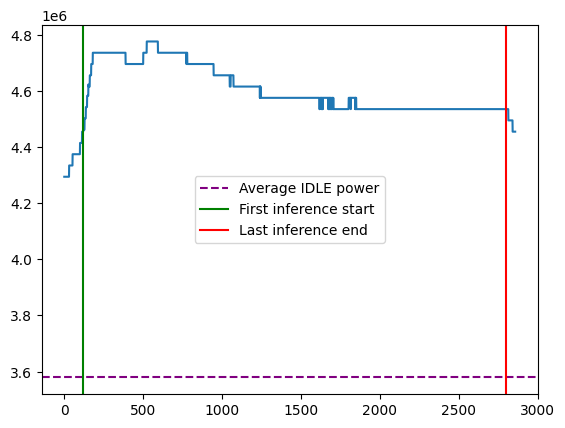

In [6]:
plt.plot([power for (_, power) in power_data])
plt.axhline(avg_power, color='purple', linestyle='--', label='Average IDLE power')
first_inference_start_index = get_power_index(power_data, latency_data[0][0][1])
last_inference_end_index = get_power_index(power_data, latency_data[2999][0][2])
plt.axvline(first_inference_start_index, color='green', label='First inference start')
plt.axvline(last_inference_end_index, color='red', label='Last inference end')
plt.legend()

In [7]:
metrics = compute_layer_metrics_by_cycle(power_data, latency_data, avg_power)
metrics_df_k1 = pd.DataFrame.from_dict(metrics)

Computing layer metrics...


Mapping power to layer: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [00:00<00:00, 1394846.69it/s]


In [8]:
metrics_df_k1.describe()

,cycle,layer_power_including_idle_power_micro_watt,layer_power_excluding_idle_power_micro_watt,layer_run_time
count,3000.000000,1.747000e+03,1.747000e+03,3000.000000
mean,1500.500000,4.608916e+06,1.029738e+06,0.816979
std,866.169729,8.262556e+04,8.262556e+04,0.115955
min,1.000000,4.454208e+06,8.750299e+05,0.381344
25%,750.750000,4.534464e+06,9.552859e+05,0.804736
50%,1500.500000,4.574592e+06,9.954139e+05,0.826864
75%,2250.250000,4.694976e+06,1.115798e+06,0.855008
max,3000.000000,4.775232e+06,1.196054e+06,3.931040


In [9]:
metrics_df_k1.count()

cycle                                          3000
layer_power_including_idle_power_micro_watt    1747
layer_power_excluding_idle_power_micro_watt    1747
layer_run_time                                 3000
dtype: int64

<Axes: >

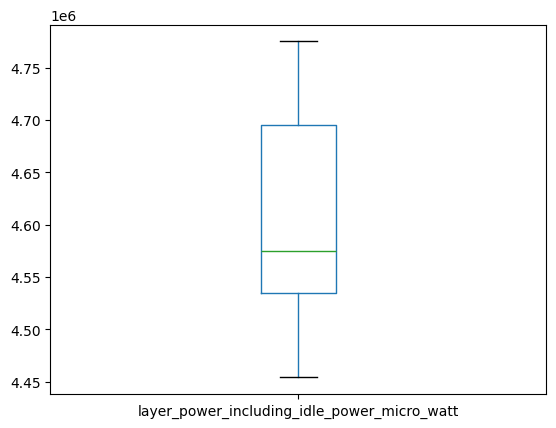

In [10]:
metrics_df_k1.boxplot(column='layer_power_including_idle_power_micro_watt', grid=False)

### Kernel 2 Stride 1 Output 3

In [11]:
model_name = 'conv_k2_s1_o3'

with open((DATA_PATH/model_name/f'{model_name}_power_log.log'), 'r') as fp:
    data = fp.readlines()
power_data = parse_power_log(data)

with open((DATA_PATH/model_name/f'{model_name}_layerwise_latency.json'), 'r') as fp:
    data = json.load(fp)
latency_data = parse_latencies(data)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2048/2048 [00:00<00:00, 130567.95it/s]
Computing layer execution times: 3000it [00:00, 439669.87it/s]


In [12]:
print(f"Number of power entries for {model_name}: {len(power_data)}")
print(f"Number of TensorRT layers in {model_name}: {len(latency_data[0])}")
print(f"Number of latency entries for each layer: {len(latency_data)}")
print(f"Inference for {len(latency_data)} cycles: {(latency_data[len(latency_data)-1][0][2]-latency_data[0][0][1]).total_seconds()} seconds")

Number of power entries for conv_k2_s1_o3: 2048
Number of TensorRT layers in conv_k2_s1_o3: 1
Number of latency entries for each layer: 3000
Inference for 3000 cycles: 2.540633 seconds


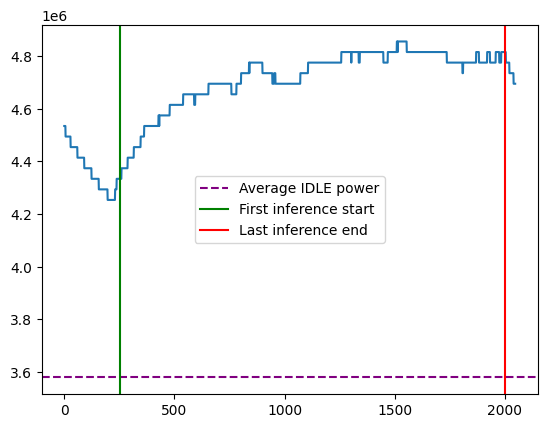

In [13]:
plt.plot([power for (_, power) in power_data])
plt.axhline(avg_power, color='purple', linestyle='--', label='Average IDLE power')
first_inference_start_index = get_power_index(power_data, latency_data[0][0][1])
last_inference_end_index = get_power_index(power_data, latency_data[2999][0][2])
plt.axvline(first_inference_start_index, color='green', label='First inference start')
plt.axvline(last_inference_end_index, color='red', label='Last inference end')
plt.legend()

In [14]:
metrics = compute_layer_metrics_by_cycle(power_data, latency_data, avg_power)
metrics_df_k2 = pd.DataFrame.from_dict(metrics)

Computing layer metrics...


Mapping power to layer: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [00:00<00:00, 1529279.53it/s]


In [15]:
metrics_df_k2.describe()

,cycle,layer_power_including_idle_power_micro_watt,layer_power_excluding_idle_power_micro_watt,layer_run_time
count,3000.000000,1.174000e+03,1.174000e+03,3000.000000
mean,1500.500000,4.719825e+06,1.140647e+06,0.570375
std,866.169729,1.109351e+05,1.109351e+05,0.058340
min,1.000000,4.333824e+06,7.546459e+05,0.461696
25%,750.750000,4.694976e+06,1.115798e+06,0.557328
50%,1500.500000,4.775232e+06,1.196054e+06,0.565216
75%,2250.250000,4.815360e+06,1.236182e+06,0.573352
max,3000.000000,4.855488e+06,1.276310e+06,3.182944


In [16]:
metrics_df_k2.count()

cycle                                          3000
layer_power_including_idle_power_micro_watt    1174
layer_power_excluding_idle_power_micro_watt    1174
layer_run_time                                 3000
dtype: int64

<Axes: >

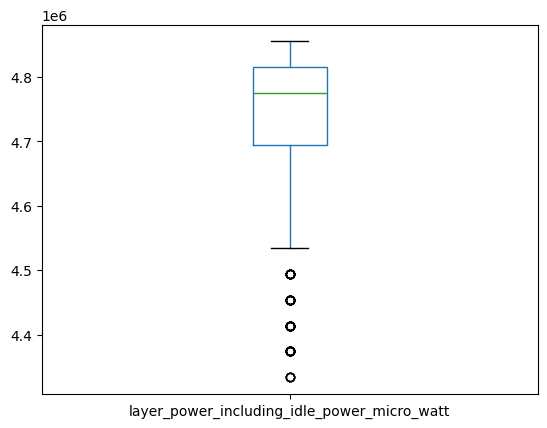

In [17]:
metrics_df_k2.boxplot(column='layer_power_including_idle_power_micro_watt', grid=False)

### Kernel 3 Stride 1 Output 3

In [18]:
model_name = 'conv_k3_s1_o3'

with open((DATA_PATH/model_name/f'{model_name}_power_log.log'), 'r') as fp:
    data = fp.readlines()
power_data = parse_power_log(data)

with open((DATA_PATH/model_name/f'{model_name}_layerwise_latency.json'), 'r') as fp:
    data = json.load(fp)
latency_data = parse_latencies(data)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3016/3016 [00:00<00:00, 121506.30it/s]
Computing layer execution times: 3000it [00:00, 448876.71it/s]


In [19]:
print(f"Number of power entries for {model_name}: {len(power_data)}")
print(f"Number of TensorRT layers in {model_name}: {len(latency_data[0])}")
print(f"Number of latency entries for each layer: {len(latency_data)}")
print(f"Inference for {len(latency_data)} cycles: {(latency_data[len(latency_data)-1][0][2]-latency_data[0][0][1]).total_seconds()} seconds")

Number of power entries for conv_k3_s1_o3: 3016
Number of TensorRT layers in conv_k3_s1_o3: 1
Number of latency entries for each layer: 3000
Inference for 3000 cycles: 3.769518 seconds


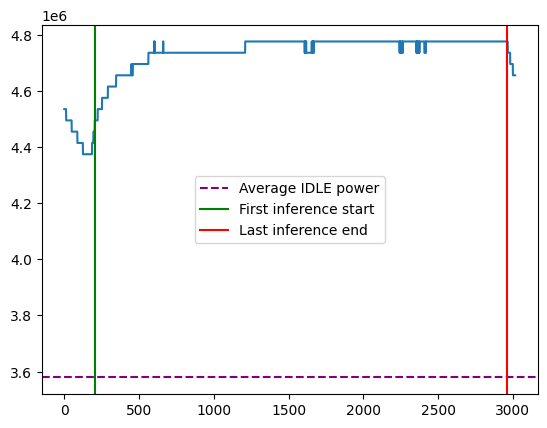

In [20]:
plt.plot([power for (_, power) in power_data])
plt.axhline(avg_power, color='purple', linestyle='--', label='Average IDLE power')
first_inference_start_index = get_power_index(power_data, latency_data[0][0][1])
last_inference_end_index = get_power_index(power_data, latency_data[2999][0][2])
plt.axvline(first_inference_start_index, color='green', label='First inference start')
plt.axvline(last_inference_end_index, color='red', label='Last inference end')
plt.legend()

In [21]:
metrics = compute_layer_metrics_by_cycle(power_data, latency_data, avg_power)
metrics_df_k3 = pd.DataFrame.from_dict(metrics)

Computing layer metrics...


Mapping power to layer: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [00:00<00:00, 839084.56it/s]


In [22]:
metrics_df_k3.describe()

,cycle,layer_power_including_idle_power_micro_watt,layer_power_excluding_idle_power_micro_watt,layer_run_time
count,3000.000000,1.809000e+03,1.809000e+03,3000.000000
mean,1500.500000,4.745996e+06,1.166818e+06,0.833181
std,866.169729,5.249158e+04,5.249158e+04,0.035864
min,1.000000,4.494336e+06,9.151579e+05,0.663104
25%,750.750000,4.735104e+06,1.155926e+06,0.819768
50%,1500.500000,4.775232e+06,1.196054e+06,0.832560
75%,2250.250000,4.775232e+06,1.196054e+06,0.842112
max,3000.000000,4.775232e+06,1.196054e+06,1.529760


In [23]:
metrics_df_k3.count()

cycle                                          3000
layer_power_including_idle_power_micro_watt    1809
layer_power_excluding_idle_power_micro_watt    1809
layer_run_time                                 3000
dtype: int64

<Axes: >

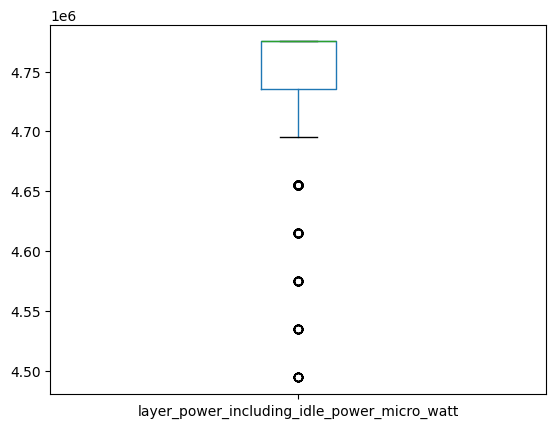

In [24]:
metrics_df_k3.boxplot(column='layer_power_including_idle_power_micro_watt', grid=False)

### Kernel 4 Stride 1 Output 3

In [25]:
model_name = 'conv_k4_s1_o3'

with open((DATA_PATH/model_name/f'{model_name}_power_log.log'), 'r') as fp:
    data = fp.readlines()
power_data = parse_power_log(data)

with open((DATA_PATH/model_name/f'{model_name}_layerwise_latency.json'), 'r') as fp:
    data = json.load(fp)
latency_data = parse_latencies(data)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3300/3300 [00:00<00:00, 154783.48it/s]
Computing layer execution times: 3000it [00:00, 1073810.55it/s]


In [26]:
print(f"Number of power entries for {model_name}: {len(power_data)}")
print(f"Number of TensorRT layers in {model_name}: {len(latency_data[0])}")
print(f"Number of latency entries for each layer: {len(latency_data)}")
print(f"Inference for {len(latency_data)} cycles: {(latency_data[len(latency_data)-1][0][2]-latency_data[0][0][1]).total_seconds()} seconds")

Number of power entries for conv_k4_s1_o3: 3300
Number of TensorRT layers in conv_k4_s1_o3: 1
Number of latency entries for each layer: 3000
Inference for 3000 cycles: 4.246261 seconds


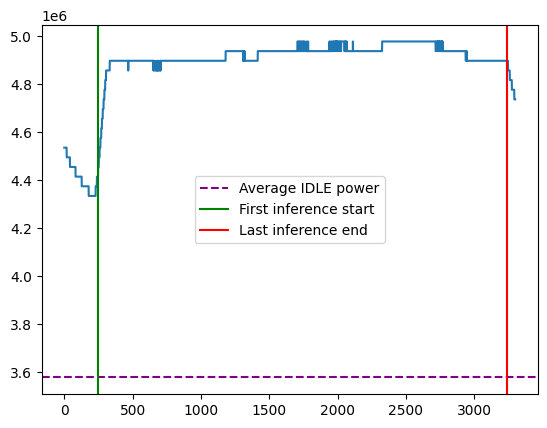

In [27]:
plt.plot([power for (_, power) in power_data])
plt.axhline(avg_power, color='purple', linestyle='--', label='Average IDLE power')
first_inference_start_index = get_power_index(power_data, latency_data[0][0][1])
last_inference_end_index = get_power_index(power_data, latency_data[2999][0][2])
plt.axvline(first_inference_start_index, color='green', label='First inference start')
plt.axvline(last_inference_end_index, color='red', label='Last inference end')
plt.legend()

In [28]:
metrics = compute_layer_metrics_by_cycle(power_data, latency_data, avg_power)
metrics_df_k4 = pd.DataFrame.from_dict(metrics)

Computing layer metrics...


Mapping power to layer: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [00:00<00:00, 1891313.99it/s]


In [29]:
metrics_df_k4.describe()

,cycle,layer_power_including_idle_power_micro_watt,layer_power_excluding_idle_power_micro_watt,layer_run_time
count,3000.000000,2.112000e+03,2.112000e+03,3000.000000
mean,1500.500000,4.920316e+06,1.341138e+06,1.023513
std,866.169729,4.789924e+04,4.789924e+04,0.112076
min,1.000000,4.454208e+06,8.750299e+05,0.388896
25%,750.750000,4.895616e+06,1.316438e+06,1.008408
50%,1500.500000,4.935744e+06,1.356566e+06,1.043120
75%,2250.250000,4.935744e+06,1.356566e+06,1.057888
max,3000.000000,4.975872e+06,1.396694e+06,2.489600


In [30]:
metrics_df_k4.count()

cycle                                          3000
layer_power_including_idle_power_micro_watt    2112
layer_power_excluding_idle_power_micro_watt    2112
layer_run_time                                 3000
dtype: int64

<Axes: >

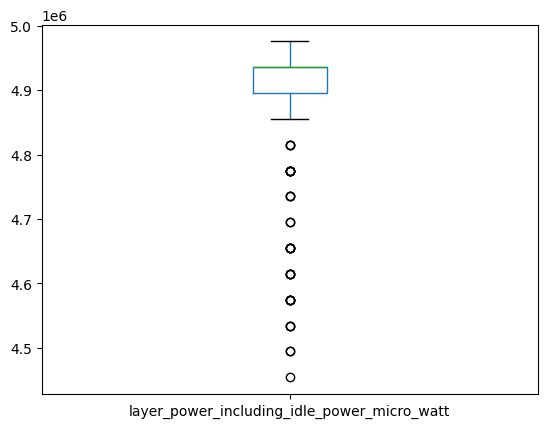

In [31]:
metrics_df_k4.boxplot(column='layer_power_including_idle_power_micro_watt', grid=False)

### Kernel 5 Stride 1 Output 3

In [32]:
model_name = 'conv_k5_s1_o3'

with open((DATA_PATH/model_name/f'{model_name}_power_log.log'), 'r') as fp:
    data = fp.readlines()
power_data = parse_power_log(data)

with open((DATA_PATH/model_name/f'{model_name}_layerwise_latency.json'), 'r') as fp:
    data = json.load(fp)
latency_data = parse_latencies(data)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3707/3707 [00:00<00:00, 132383.29it/s]
Computing layer execution times: 3000it [00:00, 475940.39it/s]


In [33]:
print(f"Number of power entries for {model_name}: {len(power_data)}")
print(f"Number of TensorRT layers in {model_name}: {len(latency_data[0])}")
print(f"Number of latency entries for each layer: {len(latency_data)}")
print(f"Inference for {len(latency_data)} cycles: {(latency_data[len(latency_data)-1][0][2]-latency_data[0][0][1]).total_seconds()} seconds")

Number of power entries for conv_k5_s1_o3: 3707
Number of TensorRT layers in conv_k5_s1_o3: 1
Number of latency entries for each layer: 3000
Inference for 3000 cycles: 4.729364 seconds


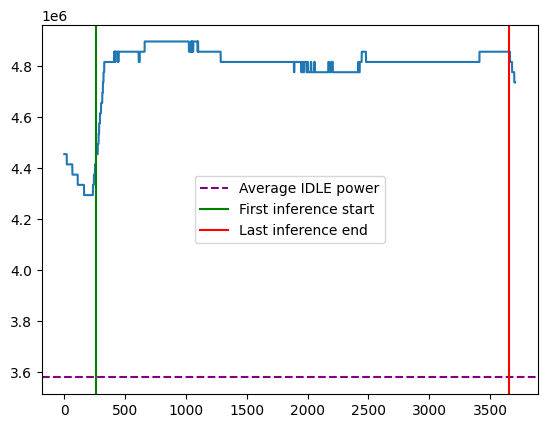

In [34]:
plt.plot([power for (_, power) in power_data])
plt.axhline(avg_power, color='purple', linestyle='--', label='Average IDLE power')
first_inference_start_index = get_power_index(power_data, latency_data[0][0][1])
last_inference_end_index = get_power_index(power_data, latency_data[2999][0][2])
plt.axvline(first_inference_start_index, color='green', label='First inference start')
plt.axvline(last_inference_end_index, color='red', label='Last inference end')
plt.legend()

In [35]:
metrics = compute_layer_metrics_by_cycle(power_data, latency_data, avg_power)
metrics_df_k5 = pd.DataFrame.from_dict(metrics)

Computing layer metrics...


Mapping power to layer: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [00:00<00:00, 1254902.96it/s]


In [36]:
metrics_df_k5.describe()

,cycle,layer_power_including_idle_power_micro_watt,layer_power_excluding_idle_power_micro_watt,layer_run_time
count,3000.000000,2.502000e+03,2.502000e+03,3000.000000
mean,1500.500000,4.825432e+06,1.246254e+06,1.160441
std,866.169729,4.763559e+04,4.763559e+04,0.124065
min,1.000000,4.414080e+06,8.349019e+05,0.433984
25%,750.750000,4.815360e+06,1.236182e+06,1.131200
50%,1500.500000,4.815360e+06,1.236182e+06,1.154144
75%,2250.250000,4.855488e+06,1.276310e+06,1.230176
max,3000.000000,4.895616e+06,1.316438e+06,2.374240


In [37]:
metrics_df_k5.count()

cycle                                          3000
layer_power_including_idle_power_micro_watt    2502
layer_power_excluding_idle_power_micro_watt    2502
layer_run_time                                 3000
dtype: int64

<Axes: >

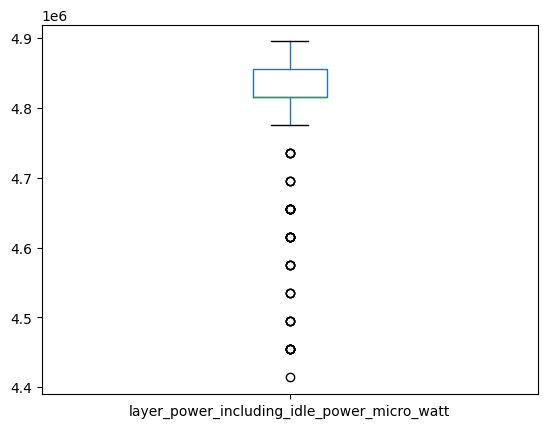

In [38]:
metrics_df_k5.boxplot(column='layer_power_including_idle_power_micro_watt', grid=False)

## Kernels Plot

Text(0.5, 0, 'Kernel size')

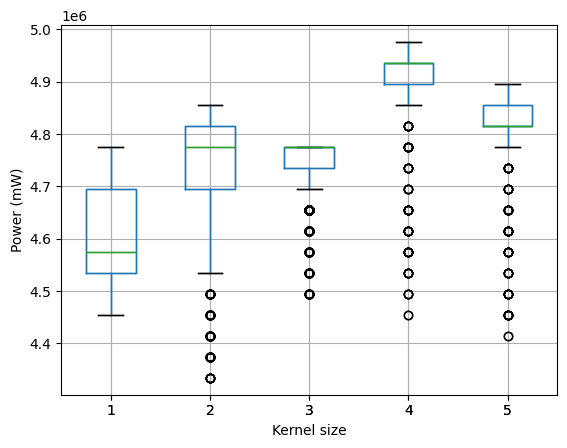

In [39]:
df = pd.concat(
    [
        metrics_df_k1["layer_power_including_idle_power_micro_watt"],
        metrics_df_k2["layer_power_including_idle_power_micro_watt"],
        metrics_df_k3["layer_power_including_idle_power_micro_watt"],
        metrics_df_k4["layer_power_including_idle_power_micro_watt"],
        metrics_df_k5["layer_power_including_idle_power_micro_watt"],
    ],
    axis=1,
)

# set column names (will be displayed as plot labels)
df.columns = ['1', '2', '3', '4', '5']  

# use pandas' boxplot method
df.boxplot().set_ylabel('Power (mW)')
df.boxplot().set_xlabel('Kernel size')